---
title: xarray EOPF backend - Sentinel-2
Subtitle: Access Sentinel-2 in Analysis Mode
authors:
  - name: Konstantin Ntokas
    orcid: 0000-0002-0049-0690
    github: konstntokas
    affiliations:
      - id: Brockmann Consult GmbH
        institution: Brockmann Consult GmbH
        ror: 04r0k9g65
reviewers:
  - name: Michele Claus
    orcid: 0000-0003-3680-381X
    github: clausmichele
    affiliations:
      - id: Eurac Research
        institution: Eurac Research
        ror: 01xt1w755
date: 2026-03-27
thumbnail: ../static/EOPF-on-bright-baseline.png
keywords: ["data access", "xarray", "EOPF Zarr products"]
tags: ["sentinel-2", "xarray-eopf", "land"]
releaseDate: 2026-03-27
datePublished: 2026-03-27
dateModified: 2026-03-27
github: https://github.com/EOPF-Sample-Service/eopf-sample-notebooks
license: Apache-2.0
---

```{image} ../static/EOPF-on-bright-baseline.png
:alt: ESA EOPF Zarr Logo
:width: 250px
:align: center
```

## Table of Contents
1. [Introduction](#Introduction_XEOPF_SEN2_ANALYSIS)
2. [Main Features of the Analysis Mode for Sentinel-2](#Main_Features_XEOPF_SEN2_ANALYSIS)
3. [Import modules](#Import_XEOPF_SEN2_ANALYSIS)
4. [Open a Sentinel-2 Level-1C](#Open_L1C_XEOPF_SEN2_ANALYSIS)
5. [Open a Sentinel-2 Level-2A](#Open_L2A_XEOPF_SEN2_ANALYSIS)
6. [Conclusion](#Conclusion_XEOPF_SEN2_ANALYSIS)

(Introduction_XEOPF_SEN2_ANALYSIS)=
## Introduction

**xarray-eopf** is a Python package that extends **xarray** with a custom backend called `"eopf-zarr"`. This backend enables **seamless access to ESA EOPF data products** stored in the **Zarr** format, presenting them as analysis-ready data structures.

In this notebook, we demonstrate how to use the **xarray-eopf** backend to access **Sentinel-2** EOPF Zarr products in **analysis mode**. All data access is *lazy*, meaning that data is only loaded when required—for example, during plotting or when writing to storage. 

For a general introduction to the xarray EOPF backend, see the [introduction notebook](https://eopf-sample-service.github.io/xarray-eopf/examples/introduction/).  
For an example of the native mode, see the [Sentinel-2 native mode notebook](https://eopf-sample-service.github.io/xarray-eopf/examples/sentinel_2_native/).


- 🐙 **GitHub:** [EOPF Sample Service – xarray-eopf](https://github.com/EOPF-Sample-Service/xarray-eopf)  
- ❗ **Issue Tracker:** [Submit or view issues](https://github.com/EOPF-Sample-Service/xarray-eopf/issues)  
- 📘 **Documentation:** [xarray-eopf Docs](https://eopf-sample-service.github.io/xarray-eopf/)

:::{hint} Overview
**Questions**
- How can I use the xarray-eopf backend for Sentinel-2 in analysis mode?
- What main features does the xarray-eopf backend provide for Sentinel-2 in analysis mode?

**Objectives**
- Learn how to open Sentinel-2 EOPF Zarr products using `xarray-eopf`.
- Understand the key features and capabilities of the `xarray-eopf` backend in analysis mode for Sentinel-2.
:::

(Main_Features_XEOPF_SEN2_ANALYSIS)=
## Main Features of the Analysis Mode for Sentinel-2

The **analysis mode** provides EOPF products as **analysis-ready `xarray.Dataset` objects** on a **single, unified spatial grid**. For Sentinel-2, this means all variables are automatically **upscaled or downscaled** so that they share a consistent pair of `x` and `y` coordinates.

### Native resolution of Sentinel-2 spectral bands

- **10 m:** B02, B03, B04, B08  
- **20 m:** B05, B06, B07, B8A, B11, B12  
- **60 m:** B01, B09, B10  

### Key properties of Sentinel-2 analysis mode

- **Default mode** for the `"eopf-zarr"` backend  
- **Selectable spatial resolution:** 10 m (default), 20 m, or 60 m  
- **Automatic resampling to align bands of different resolutions:**  
  - Upsampling via interpolation (default is `nearest` for integer arrays (e.g. Sentinel-2 L2A SCL, else `bilinear`),
  - Downsampling via aggregation (default is `center` for integer arrays (e.g. Sentinel-2 L2A SCL, else `mean`)
- **Spatial subsetting** via the `bbox` argument  
- **Reprojection** to different CRS via the `crs` argument  
- **Flexible variable selection** using names or regex patterns  

For full details on opening parameters, see the [Analysis Mode documentation](https://eopf-sample-service.github.io/xarray-eopf/guide/#analysis-mode) and, specifically for Sentinel-2, the [Sentinel-2 Analysis Mode guide](https://eopf-sample-service.github.io/xarray-eopf/guide/#sentinel-2).

---

(Import_XEOPF_SEN2_ANALYSIS)=
## Import Modules

The `xarray-eopf` backend is implemented as a plugin for `xarray`. Once installed, it registers automatically and requires no additional import. You can simply import `xarray` as usual:

In [1]:
import datetime

import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np
import pystac_client
import xarray as xr

---

(Open_L1C_XEOPF_SEN2_ANALYSIS)=
## Open a Sentinel-2 Level-1C product

We begin with an example that accesses a Sentinel-2 Level-1C product in **analysis mode**. 

### Find a Sentinel-2 Level-1C Zarr Sample via STAC

To obtain a product URL, you can use the [STAC Browser](https://stac.browser.user.eopf.eodc.eu/collections/sentinel-2-l1c) to search for a Sentinel-2 Level-1C tile. Here, the `query` parameter is used to select tiles with less than 40% cloud cover, improving the chances of a clear plot.

In [2]:
catalog = pystac_client.Client.open("https://stac.core.eopf.eodc.eu")
items = list(
    catalog.search(
        collections=["sentinel-2-l1c"],
        bbox=[7.2, 44.5, 7.4, 44.7],
        datetime=[str(datetime.date.today() - datetime.timedelta(days=30)), None],
        query={"eo:cloud_cover": {"lt": 40}},
    ).items()
)
items

[<Item id=S2A_MSIL1C_20260326T102701_N0512_R108_T32TLQ_20260326T154418>,
 <Item id=S2C_MSIL1C_20260321T101721_N0512_R065_T32TLQ_20260321T143127>,
 <Item id=S2B_MSIL1C_20260319T103019_N0512_R108_T32TLQ_20260319T145744>,
 <Item id=S2A_MSIL1C_20260316T103041_N0512_R108_T32TLQ_20260316T172545>,
 <Item id=S2B_MSIL1C_20260316T101649_N0512_R065_T32TLQ_20260316T153332>,
 <Item id=S2A_MSIL1C_20260313T101741_N0512_R065_T32TLQ_20260313T153853>,
 <Item id=S2C_MSIL1C_20260304T102921_N0512_R108_T32TLQ_20260304T140806>]

In [3]:
item = items[0]

### Open Sentinel-2 Level-1C with default parameters

We can now open the Sentinel-2 product in **analysis mode**. Since this is the default, the `op_mode` parameter does not need to be specified.  

The following cell returns a **lazy dataset**, with all bands resampled to **60 m resolution**. This lower resolution is chosen to keep plotting fast, as rendering full-resolution data in Matplotlib can be slow.

In [4]:
ds = xr.open_dataset(
    item.assets["product"].href, engine="eopf-zarr", resolution=60, chunks={}
)
ds

<xarray.Dataset> Size: 348MB
Dimensions:      (y: 1830, x: 1830)
Coordinates:
  * y            (y) float32 7kB 5e+06 5e+06 5e+06 ... 4.89e+06 4.89e+06
  * x            (x) float32 7kB 3e+05 3.001e+05 ... 4.097e+05 4.098e+05
    spatial_ref  int64 8B ...
Data variables: (12/13)
    b02          (y, x) float64 27MB dask.array<chunksize=(1830, 1830), meta=np.ndarray>
    b03          (y, x) float64 27MB dask.array<chunksize=(1830, 1830), meta=np.ndarray>
    b04          (y, x) float64 27MB dask.array<chunksize=(1830, 1830), meta=np.ndarray>
    b08          (y, x) float64 27MB dask.array<chunksize=(1830, 1830), meta=np.ndarray>
    b05          (y, x) float64 27MB dask.array<chunksize=(1830, 1830), meta=np.ndarray>
    b06          (y, x) float64 27MB dask.array<chunksize=(1830, 1830), meta=np.ndarray>
    ...           ...
    b11          (y, x) float64 27MB dask.array<chunksize=(1830, 1830), meta=np.ndarray>
    b12          (y, x) float64 27MB dask.array<chunksize=(1830, 1830), meta=np.ndarray>
    b8a          (y, x) float64 27MB dask.array<chunksize=(1830, 1830), meta=np.ndarray>
    b01          (y, x) float64 27MB dask.array<chunksize=(1830, 1830), meta=np.ndarray>
    b09          (y, x) float64 27MB dask.array<chunksize=(1830, 1830), meta=np.ndarray>
    b10          (y, x) float64 27MB dask.array<chunksize=(1830, 1830), meta=np.ndarray>
Attributes: (25)

As an example, we plot the red band (`b04`), which triggers the loading and visualization of the data. Note that the red band is only available at 10 m resolution in the Level-1C product. Therefore, when plotting, the array is first loaded at 10 m resolution and then aggregated before being displayed, which may take some time.

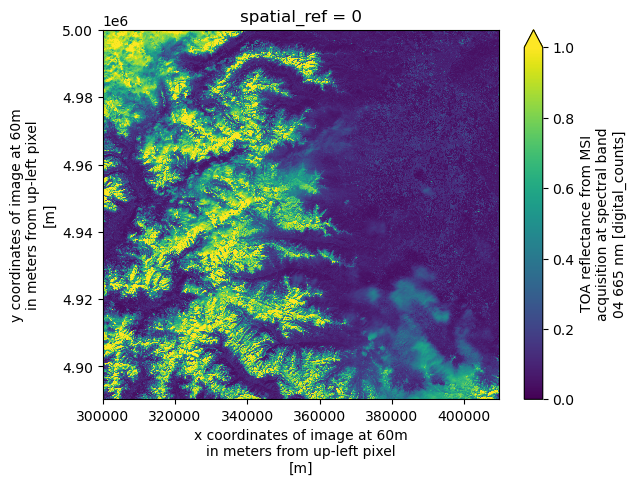

In [5]:
ds.b04.plot(vmin=0.0, vmax=1.0)

### Spatial Resampling, Subsetting and Reprojection

We can also change the resolution and display only a subset of the data by specifying the `bbox` argument, as shown below.

In [6]:
ds = xr.open_dataset(
    item.assets["product"].href,
    engine="eopf-zarr",
    resolution=10,
    bbox=[340000, 4900000, 360000, 4920000],
    chunks={},
)
ds

<xarray.Dataset> Size: 416MB
Dimensions:      (y: 2000, x: 2000)
Coordinates:
  * y            (y) float64 16kB 4.92e+06 4.92e+06 4.92e+06 ... 4.9e+06 4.9e+06
  * x            (x) float64 16kB 3.4e+05 3.4e+05 3.4e+05 ... 3.6e+05 3.6e+05
    spatial_ref  int64 8B ...
Data variables: (12/13)
    b02          (y, x) float64 32MB dask.array<chunksize=(1830, 1830), meta=np.ndarray>
    b03          (y, x) float64 32MB dask.array<chunksize=(1830, 1830), meta=np.ndarray>
    b04          (y, x) float64 32MB dask.array<chunksize=(1830, 1830), meta=np.ndarray>
    b08          (y, x) float64 32MB dask.array<chunksize=(1830, 1830), meta=np.ndarray>
    b05          (y, x) float64 32MB dask.array<chunksize=(1830, 1830), meta=np.ndarray>
    b06          (y, x) float64 32MB dask.array<chunksize=(1830, 1830), meta=np.ndarray>
    ...           ...
    b11          (y, x) float64 32MB dask.array<chunksize=(1830, 1830), meta=np.ndarray>
    b12          (y, x) float64 32MB dask.array<chunksize=(1830, 1830), meta=np.ndarray>
    b8a          (y, x) float64 32MB dask.array<chunksize=(1830, 1830), meta=np.ndarray>
    b01          (y, x) float64 32MB dask.array<chunksize=(1830, 1830), meta=np.ndarray>
    b09          (y, x) float64 32MB dask.array<chunksize=(1830, 1830), meta=np.ndarray>
    b10          (y, x) float64 32MB dask.array<chunksize=(1830, 1830), meta=np.ndarray>
Attributes: (25)

As an example, we plot again the red band (`b04`).

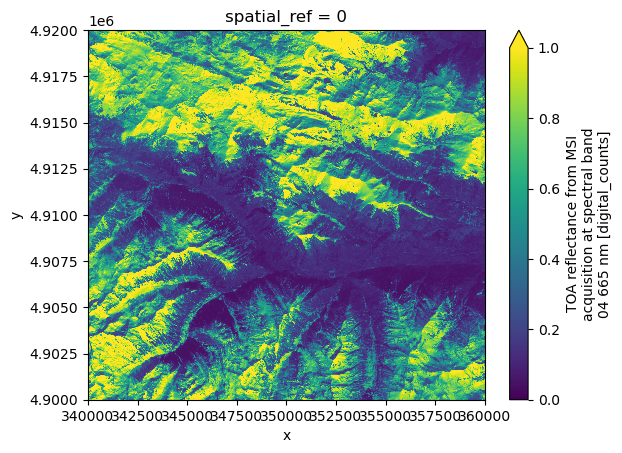

In [7]:
ds.b04.plot(vmin=0.0, vmax=1.0)

We can request the same area in **WGS84 geographic coordinates** by specifying `crs="EPSG:4326"`. Note that both the `resolution` and `bbox` must be provided in the CRS units (i.e., degrees).

In [8]:
ds = xr.open_dataset(
    item.assets["product"].href,
    engine="eopf-zarr",
    resolution=0.0002,
    crs="EPSG:4326",
    bbox=[7.0, 44.2, 7.3, 44.4],
    chunks={},
)
ds

<xarray.Dataset> Size: 156MB
Dimensions:      (lon: 1500, lat: 1000)
Coordinates:
  * lon          (lon) float64 12kB 7.0 7.0 7.0 7.001 ... 7.299 7.3 7.3 7.3
  * lat          (lat) float64 8kB 44.4 44.4 44.4 44.4 ... 44.2 44.2 44.2 44.2
    spatial_ref  int64 8B ...
Data variables: (12/13)
    b02          (lat, lon) float64 12MB dask.array<chunksize=(1000, 1500), meta=np.ndarray>
    b03          (lat, lon) float64 12MB dask.array<chunksize=(1000, 1500), meta=np.ndarray>
    b04          (lat, lon) float64 12MB dask.array<chunksize=(1000, 1500), meta=np.ndarray>
    b08          (lat, lon) float64 12MB dask.array<chunksize=(1000, 1500), meta=np.ndarray>
    b05          (lat, lon) float64 12MB dask.array<chunksize=(1000, 1500), meta=np.ndarray>
    b06          (lat, lon) float64 12MB dask.array<chunksize=(1000, 1500), meta=np.ndarray>
    ...           ...
    b11          (lat, lon) float64 12MB dask.array<chunksize=(1000, 1500), meta=np.ndarray>
    b12          (lat, lon) float64 12MB dask.array<chunksize=(1000, 1500), meta=np.ndarray>
    b8a          (lat, lon) float64 12MB dask.array<chunksize=(1000, 1500), meta=np.ndarray>
    b01          (lat, lon) float64 12MB dask.array<chunksize=(1000, 1500), meta=np.ndarray>
    b09          (lat, lon) float64 12MB dask.array<chunksize=(1000, 1500), meta=np.ndarray>
    b10          (lat, lon) float64 12MB dask.array<chunksize=(1000, 1500), meta=np.ndarray>
Attributes: (25)

For comparison, we plot the red band (`b04`).

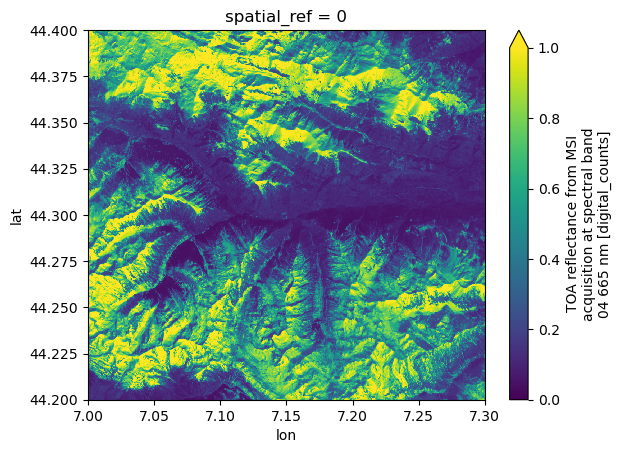

In [9]:
ds.b04.plot(vmin=0.0, vmax=1.0)

### Explore Different Aggregation Methods

As mentioned above, the default aggregation method for spectral bands during downsampling is to take the **mean** of each superpixel. We can also specify the aggregation method via the keyword argument `agg_methods`, which will be demonstrated in the next cell.

> Note: The **interpolation method** can also be specified when upsampling via the keyword argument `interp_methods`. Both keywords can be also a mapping from varaible name or data type to resampling method. More details are available in the [Analysis Mode documentation](https://eopf-sample-service.github.io/xarray-eopf/guide/#analysis-mode).

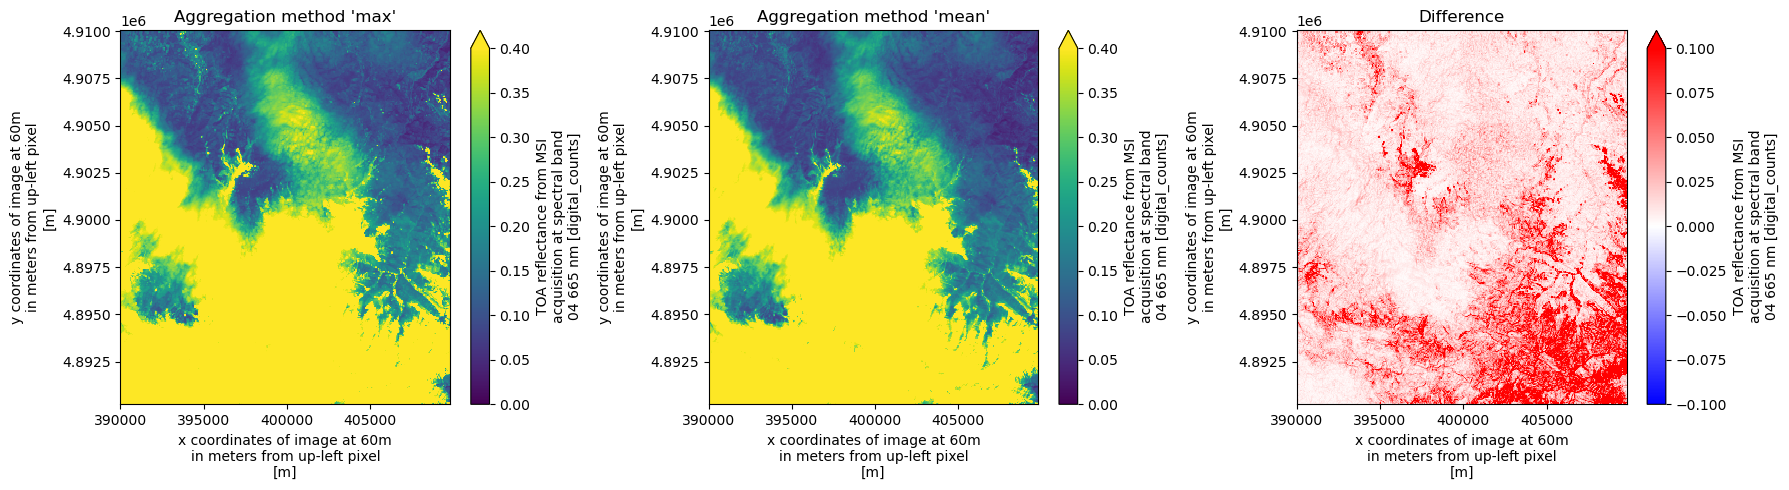

In [10]:
ds_agg_max = xr.open_dataset(
    item.assets["product"].href,
    engine="eopf-zarr",
    chunks={},
    resolution=60,
    agg_methods="max",
)
ds_agg_mean = xr.open_dataset(
    item.assets["product"].href, engine="eopf-zarr", chunks={}, resolution=60
)

fig, ax = plt.subplots(1, 3, figsize=(18, 5))
ds_agg_max.b04[1500:, 1500:].plot(ax=ax[0], vmin=0.0, vmax=0.6)
ax[0].set_title("Aggregation method 'max'")
ds_agg_mean.b04[1500:, 1500:].plot(ax=ax[1], vmin=0.0, vmax=0.6)
ax[1].set_title("Aggregation method 'mean'")
(ds_agg_max.b04 - ds_agg_mean.b04)[1500:, 1500:].plot(
    ax=ax[2], vmin=-0.1, vmax=0.1, cmap="bwr"
)
ax[2].set_title("Difference")
plt.tight_layout()

### Support for Common Band Names

Support has been added for **common band names** from the [STAC EO extension](https://github.com/stac-extensions/eo?tab=readme-ov-file#common-band-names) in **Sentinel-2 analysis mode**.  

The `variables` parameter now accepts standard spectral names such as `blue`, `green`, `red`, `nir`, and others.

The next cell demonstrates an example where we filter spectral bands using these common names.

In [11]:
ds = xr.open_dataset(
    item.assets["product"].href,
    engine="eopf-zarr",
    chunks={},
    resolution=60,
    variables=["red", "green", "blue", "nir"],
)
ds

<xarray.Dataset> Size: 107MB
Dimensions:      (y: 1830, x: 1830)
Coordinates:
  * y            (y) float64 15kB 5e+06 5e+06 5e+06 ... 4.89e+06 4.89e+06
  * x            (x) float64 15kB 3e+05 3.001e+05 ... 4.097e+05 4.098e+05
    spatial_ref  int64 8B ...
Data variables:
    blue         (y, x) float64 27MB dask.array<chunksize=(305, 305), meta=np.ndarray>
    green        (y, x) float64 27MB dask.array<chunksize=(305, 305), meta=np.ndarray>
    red          (y, x) float64 27MB dask.array<chunksize=(305, 305), meta=np.ndarray>
    nir          (y, x) float64 27MB dask.array<chunksize=(305, 305), meta=np.ndarray>
Attributes: (25)

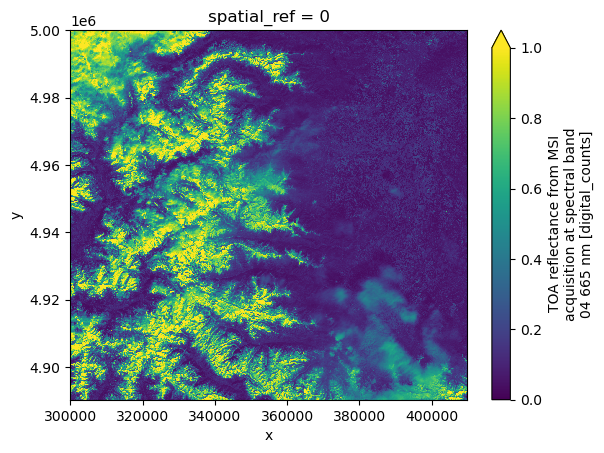

In [12]:
ds.red.plot(vmin=0.0, vmax=1.0)

(Open_L2A_XEOPF_SEN2_ANALYSIS)=
## Open Sentinel-2 Level-2A product

### Find a Sentinel-2 Level-2A Zarr Sample via STAC

To obtain a product URL, you can use the [STAC Browser](https://stac.browser.user.eopf.eodc.eu/collections/sentinel-2-l2a) to search for available Sentinel-2 Level-2A tiles. Also here, the `query` parameter is used to select tiles with less than 40% cloud cover, improving the chances of a clear plot.

In [13]:
catalog = pystac_client.Client.open("https://stac.core.eopf.eodc.eu")
items = list(
    catalog.search(
        collections=["sentinel-2-l2a"],
        bbox=[7.2, 44.5, 7.4, 44.7],
        datetime=[str(datetime.date.today() - datetime.timedelta(days=30)), None],
        query={"eo:cloud_cover": {"lt": 40}},
    ).items()
)
items

[<Item id=S2A_MSIL2A_20260326T102701_N0512_R108_T32TLQ_20260326T172711>,
 <Item id=S2B_MSIL2A_20260326T102019_N0512_R065_T32TLQ_20260326T155529>,
 <Item id=S2B_MSIL2A_20260319T103019_N0512_R108_T32TLQ_20260319T151320>,
 <Item id=S2A_MSIL2A_20260316T103041_N0512_R108_T32TLQ_20260316T184508>,
 <Item id=S2B_MSIL2A_20260316T101649_N0512_R065_T32TLQ_20260316T155405>,
 <Item id=S2A_MSIL2A_20260313T101741_N0512_R065_T32TLQ_20260313T171916>,
 <Item id=S2C_MSIL2A_20260304T102921_N0512_R108_T32TLQ_20260304T160811>]

In [14]:
item = items[0]

In [15]:
ds = xr.open_dataset(
    item.assets["product"].href,
    engine="eopf-zarr",
    chunks={},
    resolution=60,
)
ds

<xarray.Dataset> Size: 352MB
Dimensions:      (y: 1830, x: 1830)
Coordinates:
  * y            (y) float32 7kB 5e+06 5e+06 5e+06 ... 4.89e+06 4.89e+06
  * x            (x) float32 7kB 3e+05 3.001e+05 ... 4.097e+05 4.098e+05
    spatial_ref  int64 8B ...
Data variables: (12/15)
    b08          (y, x) float64 27MB dask.array<chunksize=(1830, 1830), meta=np.ndarray>
    cld          (y, x) float32 13MB dask.array<chunksize=(1830, 1830), meta=np.ndarray>
    snw          (y, x) float32 13MB dask.array<chunksize=(1830, 1830), meta=np.ndarray>
    b01          (y, x) float64 27MB dask.array<chunksize=(1830, 1830), meta=np.ndarray>
    b02          (y, x) float64 27MB dask.array<chunksize=(1830, 1830), meta=np.ndarray>
    b03          (y, x) float64 27MB dask.array<chunksize=(1830, 1830), meta=np.ndarray>
    ...           ...
    b07          (y, x) float64 27MB dask.array<chunksize=(1830, 1830), meta=np.ndarray>
    b09          (y, x) float64 27MB dask.array<chunksize=(1830, 1830), meta=np.ndarray>
    b11          (y, x) float64 27MB dask.array<chunksize=(1830, 1830), meta=np.ndarray>
    b12          (y, x) float64 27MB dask.array<chunksize=(1830, 1830), meta=np.ndarray>
    b8a          (y, x) float64 27MB dask.array<chunksize=(1830, 1830), meta=np.ndarray>
    scl          (y, x) uint8 3MB dask.array<chunksize=(1830, 1830), meta=np.ndarray>
Attributes: (25)

### Open Sentinel-2 Level-2A with default parameters

We can now open the Sentinel-2 product in **analysis mode**.

Also here, the following cell returns a **lazy dataset**, with all bands resampled to **60 m resolution**. This lower resolution is chosen to keep plotting fast, as above.

For the **SCL** variable, the flag names, values, and corresponding colors are stored in the attributes to simplify visualization. The colors follow the
[Sentinel Hub specifications](https://custom-scripts.sentinel-hub.com/custom-scripts/sentinel-2/scene-classification/).

In the next cell, we use these flag values and names to plot the categorical **SCL** dataset.

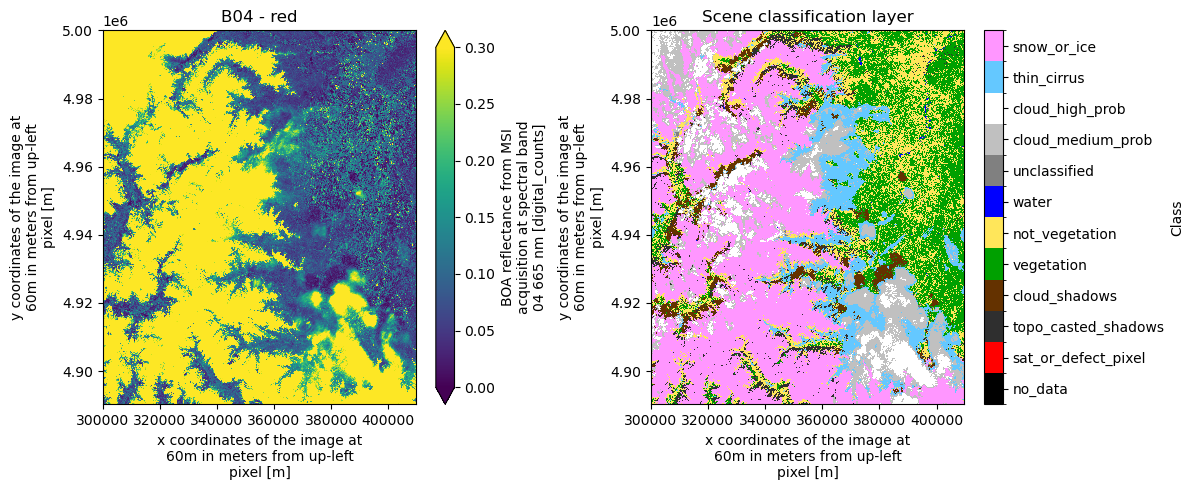

In [16]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ds.b04.plot(ax=ax[0], vmin=0.0, vmax=0.3)
ax[0].set_title("B04 - red")

cmap = mcolors.ListedColormap(ds.scl.attrs["flag_colors"].split(" "))
nb_colors = len(ds.scl.attrs["flag_values"])
norm = mcolors.BoundaryNorm(
    boundaries=np.arange(nb_colors + 1) - 0.5, ncolors=nb_colors
)
im = ds.scl.plot.imshow(ax=ax[1], cmap=cmap, norm=norm, add_colorbar=False)
cbar = fig.colorbar(im, ax=ax[1], ticks=ds.scl.attrs["flag_values"])
cbar.ax.set_yticklabels(ds.scl.attrs["flag_meanings"].split(" "))
cbar.set_label("Class")
ax[1].set_title("Scene classification layer")

plt.tight_layout()

(Conclusion_XEOPF_SEN2_ANALYSIS)=
## Conclusion

This notebook demonstrates how to access Sentinel-2 EOPF Zarr samples in **analysis mode** using the **xarray-eopf** plugin. The key takeaways are:

- **Analysis mode** is the default `op_mode`.
- In analysis mode, Sentinel-2 variables are automatically **resampled (upscaled or downscaled)** to share a consistent set of `x` and `y` coordinates.
- Data can be accessed lazily at a **user-defined resolution, bounding box, and CRS**, enabling flexible resampling, subsetting, and reprojection.
- Common band names defined by the [STAC EO extension](https://github.com/stac-extensions/eo?tab=readme-ov-file#common-band-names) are supported for variable selection.
- **Aggregation and interpolation methods** can be customized by the user for both downsampling and upsampling.
- **Scene Classification Layer (SCL)** attributes include flag values, meanings, and colors, which can be used directly for visualization.

> **Note:** This notebook only covers **analysis mode** for Sentinel-2. To learn more about **native mode**, see the [Sentinel-2 native mode notebook](https://eopf-sample-service.github.io/xarray-eopf/examples/sentinel_2_native/).

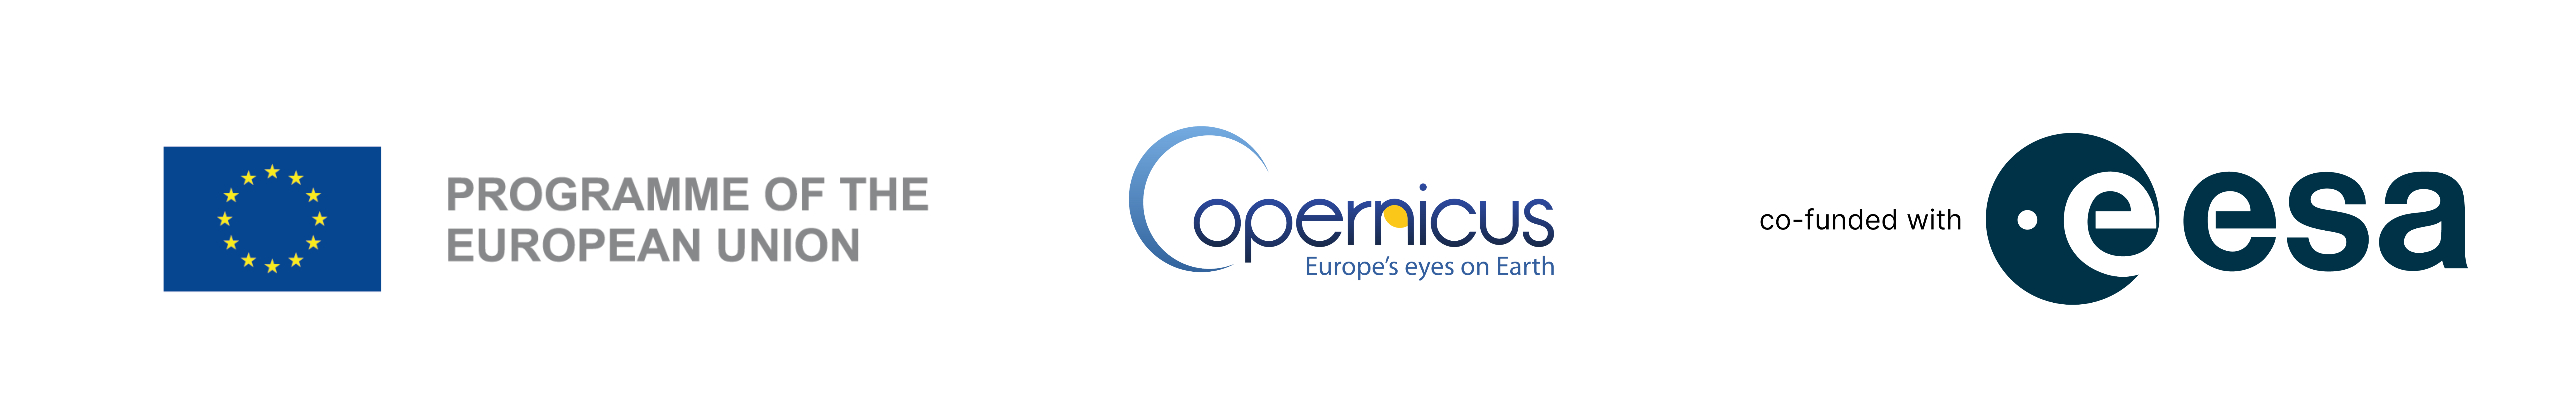